In [1]:
import os
import warnings
import itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
import time
timestr = time.strftime("%Y%m%d-%H%M%S")
%matplotlib inline
#%pip install ptitprince
import ptitprince as pt
sns.reset_orig()
sns.set(style="whitegrid",font_scale=2)


In [2]:
# plotting params
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e4e4e4",
    "grid.linewidth":    0.05,
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"

### Read data

In [3]:
# reduce data size
dtype_map = {
    'srch_id': 'int32', 'site_id': 'int16',
    'prop_id': 'int32', 'prop_starrating': 'int8',
    'prop_brand_bool': 'int8', 'promotion_flag': 'int8',
    'srch_length_of_stay': 'int16', 'srch_booking_window': 'int16',
    'srch_adults_count': 'int8', 'srch_children_count': 'int8',
    'srch_room_count': 'int8', 'srch_saturday_night_bool': 'int8',
    'random_bool': 'int8', 'click_bool': 'int8', 'booking_bool': 'int8',
    'position': 'int16',
}

In [4]:
data_path = r"C:\Users\annad\Documents\UvAnna x VU\Data Mining\Assignment 2\training_set_VU_DM.csv" #'/content/DMT_data'
#data_path = '../data'
#train_file = os.path.join(data_path, 'training_set_VU_DM.csv')
#test_file = os.path.join(data_path, 'test_set_VU_DM.csv')

df = pd.read_csv(data_path, dtype=dtype_map)
# downcast floats
for col in df.select_dtypes('float64').columns:
    df[col] = df[col].astype('float32')
display(df.head())
#test = pd.read_csv(test_file)
df.shape

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


(4958347, 54)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4958347 entries, 0 to 4958346
Data columns (total 54 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   srch_id                      int32  
 1   date_time                    str    
 2   site_id                      int16  
 3   visitor_location_country_id  int64  
 4   visitor_hist_starrating      float32
 5   visitor_hist_adr_usd         float32
 6   prop_country_id              int64  
 7   prop_id                      int32  
 8   prop_starrating              int8   
 9   prop_review_score            float32
 10  prop_brand_bool              int8   
 11  prop_location_score1         float32
 12  prop_location_score2         float32
 13  prop_log_historical_price    float32
 14  position                     int16  
 15  price_usd                    float32
 16  promotion_flag               int8   
 17  srch_destination_id          int64  
 18  srch_length_of_stay          int16  
 19  srch_bookin

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns #numeric columns

# calculate basic stats
stats = df[numeric_cols].describe().T

# calculate missing values
stats["missing"] = df[numeric_cols].isnull().sum()
stats["missing %"] = (stats["missing"] / len(df) * 100).round(1)
stats = stats.sort_values("missing %", ascending=False) # sort by missing %
display(stats)

,count,mean,std,min,25%,50%,75%,max,missing,missing %
comp1_rate_percent_diff,94439.0,244.229996,1165.511475,2.000000,7.000000,10.000000,16.000000,3.038900e+04,4863908,98.1
comp6_rate_percent_diff,96174.0,17.250473,31.164581,2.000000,6.000000,11.000000,18.000000,1.620000e+03,4862173,98.1
comp1_rate,119930.0,0.479788,0.641596,-1.000000,0.000000,1.000000,1.000000,1.000000e+00,4838417,97.6
comp1_inv,129559.0,0.031059,0.229717,-1.000000,0.000000,0.000000,0.000000,1.000000e+00,4828788,97.4
comp4_rate_percent_diff,131086.0,175.316574,5756.173340,2.000000,7.000000,11.000000,19.000000,1.001584e+06,4827261,97.4
gross_bookings_usd,138390.0,386.283295,821.172607,0.000000,124.000000,218.399994,429.790009,1.592924e+05,4819957,97.2
comp7_rate_percent_diff,138515.0,19.433268,54.368450,2.000000,7.000000,12.000000,20.000000,9.900000e+03,4819832,97.2
comp6_rate,240157.0,0.128329,0.559596,-1.000000,0.000000,0.000000,0.000000,1.000000e+00,4718190,95.2
visitor_hist_adr_usd,252988.0,176.022583,107.248199,0.000000,109.809998,152.240005,213.490005,1.958700e+03,4705359,94.9
visitor_hist_starrating,251866.0,3.374335,0.692458,1.410000,2.920000,3.450000,3.930000,5.000000e+00,4706481,94.9


In [7]:
print("Unique users:", df["srch_id"].nunique())
print("Unique hotels:", df["prop_id"].nunique())
print("First date:", df["date_time"].min())
print("Last date:", df["date_time"].max())

Unique users: 199795
Unique hotels: 129113
First date: 2012-11-01 00:08:29
Last date: 2013-06-30 23:58:24


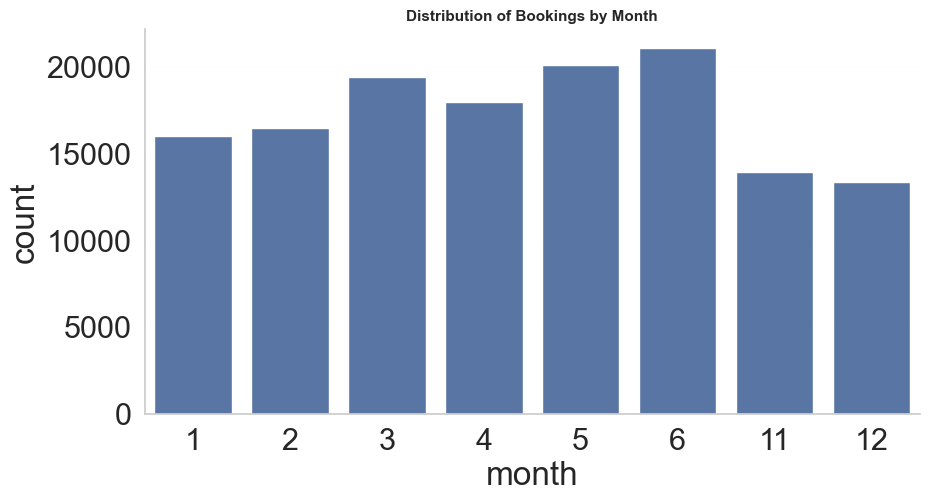

In [8]:
def get_datetime(data):
    df['date_time'] = pd.to_datetime(df['date_time'])
    data['month'] = data['date_time'].dt.month
    data['day_of_week'] = data['date_time'].dt.dayofweek
    data['hour'] = data['date_time'].dt.hour
    data["year"] = data['date_time'].dt.year
    return data

df = get_datetime(df)

# booking distribution by month
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['booking_bool'] == 1], x='month')
plt.title('Distribution of Bookings by Month')
plt.show()

Interpretation: interestingly in the training data we do not have any bookings from July-October. Probably they split the data November-June -> training, and July-October -> test

In [9]:
df.columns.tolist()

['srch_id',
 'date_time',
 'site_id',
 'visitor_location_country_id',
 'visitor_hist_starrating',
 'visitor_hist_adr_usd',
 'prop_country_id',
 'prop_id',
 'prop_starrating',
 'prop_review_score',
 'prop_brand_bool',
 'prop_location_score1',
 'prop_location_score2',
 'prop_log_historical_price',
 'position',
 'price_usd',
 'promotion_flag',
 'srch_destination_id',
 'srch_length_of_stay',
 'srch_booking_window',
 'srch_adults_count',
 'srch_children_count',
 'srch_room_count',
 'srch_saturday_night_bool',
 'srch_query_affinity_score',
 'orig_destination_distance',
 'random_bool',
 'comp1_rate',
 'comp1_inv',
 'comp1_rate_percent_diff',
 'comp2_rate',
 'comp2_inv',
 'comp2_rate_percent_diff',
 'comp3_rate',
 'comp3_inv',
 'comp3_rate_percent_diff',
 'comp4_rate',
 'comp4_inv',
 'comp4_rate_percent_diff',
 'comp5_rate',
 'comp5_inv',
 'comp5_rate_percent_diff',
 'comp6_rate',
 'comp6_inv',
 'comp6_rate_percent_diff',
 'comp7_rate',
 'comp7_inv',
 'comp7_rate_percent_diff',
 'comp8_rate',


### Nulls

In [10]:
df.isnull().sum()

srch_id                              0
date_time                            0
site_id                              0
visitor_location_country_id          0
visitor_hist_starrating        4706481
visitor_hist_adr_usd           4705359
prop_country_id                      0
prop_id                              0
prop_starrating                      0
prop_review_score                 7364
prop_brand_bool                      0
prop_location_score1                 0
prop_location_score2           1090348
prop_log_historical_price            0
position                             0
price_usd                            0
promotion_flag                       0
srch_destination_id                  0
srch_length_of_stay                  0
srch_booking_window                  0
srch_adults_count                    0
srch_children_count                  0
srch_room_count                      0
srch_saturday_night_bool             0
srch_query_affinity_score      4640941
orig_destination_distance

In [11]:
# % of missing values per column
missing_col_pct = (df.isnull().sum() / len(df)) * 100

# descending order sort
missing_col_pct = missing_col_pct.sort_values(ascending=False)

# only columns with some missing data
display(missing_col_pct[missing_col_pct > 0])

comp1_rate_percent_diff      98.095353
comp6_rate_percent_diff      98.060362
comp1_rate                   97.581250
comp1_inv                    97.387053
comp4_rate_percent_diff      97.356256
gross_bookings_usd           97.208949
comp7_rate_percent_diff      97.206428
comp6_rate                   95.156511
visitor_hist_starrating      94.920364
visitor_hist_adr_usd         94.897735
comp6_inv                    94.736633
comp4_rate                   93.800797
comp7_rate                   93.640058
srch_query_affinity_score    93.598552
comp4_inv                    93.069001
comp7_inv                    92.811677
comp3_rate_percent_diff      90.464625
comp2_rate_percent_diff      88.781786
comp8_rate_percent_diff      87.602118
comp5_rate_percent_diff      83.036706
comp3_rate                   69.056462
comp3_inv                    66.702814
comp8_rate                   61.344900
comp8_inv                    59.916016
comp2_rate                   59.166392
comp2_inv                

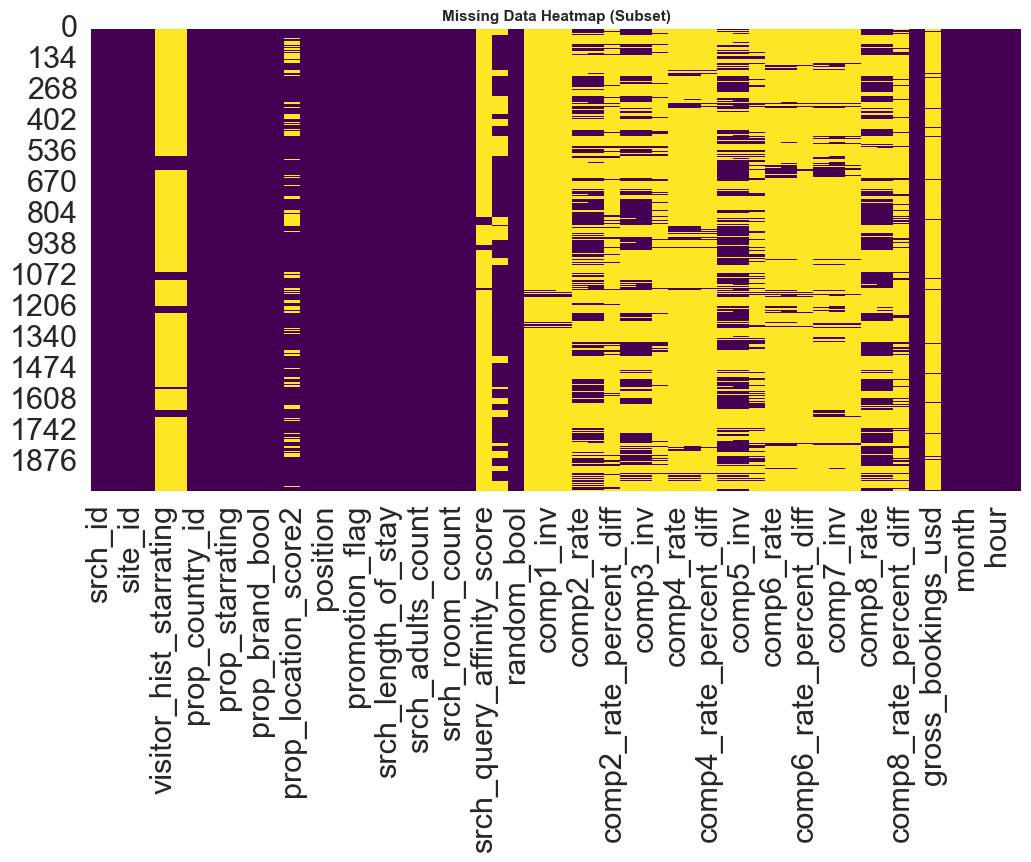

In [12]:
# visualise the first 2000 rows to see if there is any clustering in the missing data (for the first 2000 rows, as the dataset is large)
plt.figure(figsize=(12, 6))
sns.heatmap(df.iloc[:2000].isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap (Subset)")
plt.show()

interpretation: yellow is missing data, purple is where data is present. Where both columns are yellow - both feautres are not present.

In [13]:
# check consistencies within user search and hotel data
# check if missingness is consistent within the same user
user_missing = df.groupby('srch_id')['visitor_hist_starrating'].apply(
    lambda x: x.isnull().all() or x.notnull().all()
)
print("visitor_hist consistent within search:", user_missing.mean())
# should be around 1, since if a user has no history, all rows are null

# check for hotel-level consistency
hotel_missing = df.groupby('prop_id')['prop_review_score'].apply(
    lambda x: x.isnull().all() or x.notnull().all()
)
print("prop_review_score consistent within hotel:", hotel_missing.mean()) # same here 

visitor_hist consistent within search: 1.0
prop_review_score consistent within hotel: 1.0


In [14]:
# check if gross_bookings_usd is missing when booking_bool is 0
missing_logic = df.groupby('booking_bool')['gross_bookings_usd'].apply(lambda x: x.isnull().mean() * 100)
print(f"Percentage of missing 'gross_bookings_usd' by 'booking_bool':\n{missing_logic}")

# makes sense since gross_bookings_usd should only be filled when there is a booking (booking_bool=1)

Percentage of missing 'gross_bookings_usd' by 'booking_bool':
booking_bool
0    100.0
1      0.0
Name: gross_bookings_usd, dtype: float64


In [15]:
# check consistency in competitor data
# check how many competitor columns have data per row
comp_rate_cols = [c for c in df.columns if 'rate' in c and 'comp' in c]
df['comp_data_count'] = df[comp_rate_cols].notnull().sum(axis=1)
print(df['comp_data_count'].value_counts(normalize=True).sort_index())

comp_data_count
0     3.462460e-01
1     7.305943e-02
2     1.286066e-01
3     1.444814e-01
4     1.432661e-01
5     5.926552e-02
6     5.984313e-02
7     1.687942e-02
8     2.440188e-02
9     1.307694e-03
10    2.058347e-03
11    1.968398e-04
12    3.872258e-04
13    4.033602e-07
Name: proportion, dtype: float64


Interpretation: 34% of listings do not have any competitor data

In [16]:
for i in range(1, 9):
    rate_col = f'comp{i}_rate'
    diff_col = f'comp{i}_rate_percent_diff'
    inv_col  = f'comp{i}_inv'
    
    rate_null = df[rate_col].isnull()
    diff_null = df[diff_col].isnull()
    inv_null  = df[inv_col].isnull()
    
    # this should be 0: no rate means no percentage diff possible
    inconsistent_diff = (rate_null & ~diff_null).sum()
    
    # this can be non-zero and is not necessarily 
    # it means: competitor unavailability known, but price not collected
    inv_without_rate = (rate_null & ~inv_null).sum()
    
    print(f"comp{i}:")
    print(f"  rate null but diff present (check inconsistency): "
          f"{inconsistent_diff:,}")
    print(f"  rate null but inv present: "
          f"{inv_without_rate:,}")

comp1:
  rate null but diff present (check inconsistency): 0
  rate null but inv present: 9,629
comp2:
  rate null but diff present (check inconsistency): 0
  rate null but inv present: 105,597
comp3:
  rate null but diff present (check inconsistency): 0
  rate null but inv present: 116,702
comp4:
  rate null but diff present (check inconsistency): 0
  rate null but inv present: 36,285
comp5:
  rate null but diff present (check inconsistency): 0
  rate null but inv present: 137,647
comp6:
  rate null but diff present (check inconsistency): 0
  rate null but inv present: 20,819
comp7:
  rate null but diff present (check inconsistency): 0
  rate null but inv present: 41,074
comp8:
  rate null but diff present (check inconsistency): 0
  rate null but inv present: 70,849


In [17]:
# for a given hotel, are the same competitors consistently missing across searches? 
# check with first competitor
hotel_comp_missing = df.groupby('prop_id')['comp1_rate'].apply(
    lambda x: x.isnull().mean()
)
print(hotel_comp_missing.value_counts(normalize=True).head())
# if mostly 1s, missingness is hotel-level (some hotels never have comp{i} data)

comp1_rate
1.000000    0.965000
0.500000    0.001596
0.666667    0.000991
0.333333    0.000767
0.750000    0.000682
Name: proportion, dtype: float64


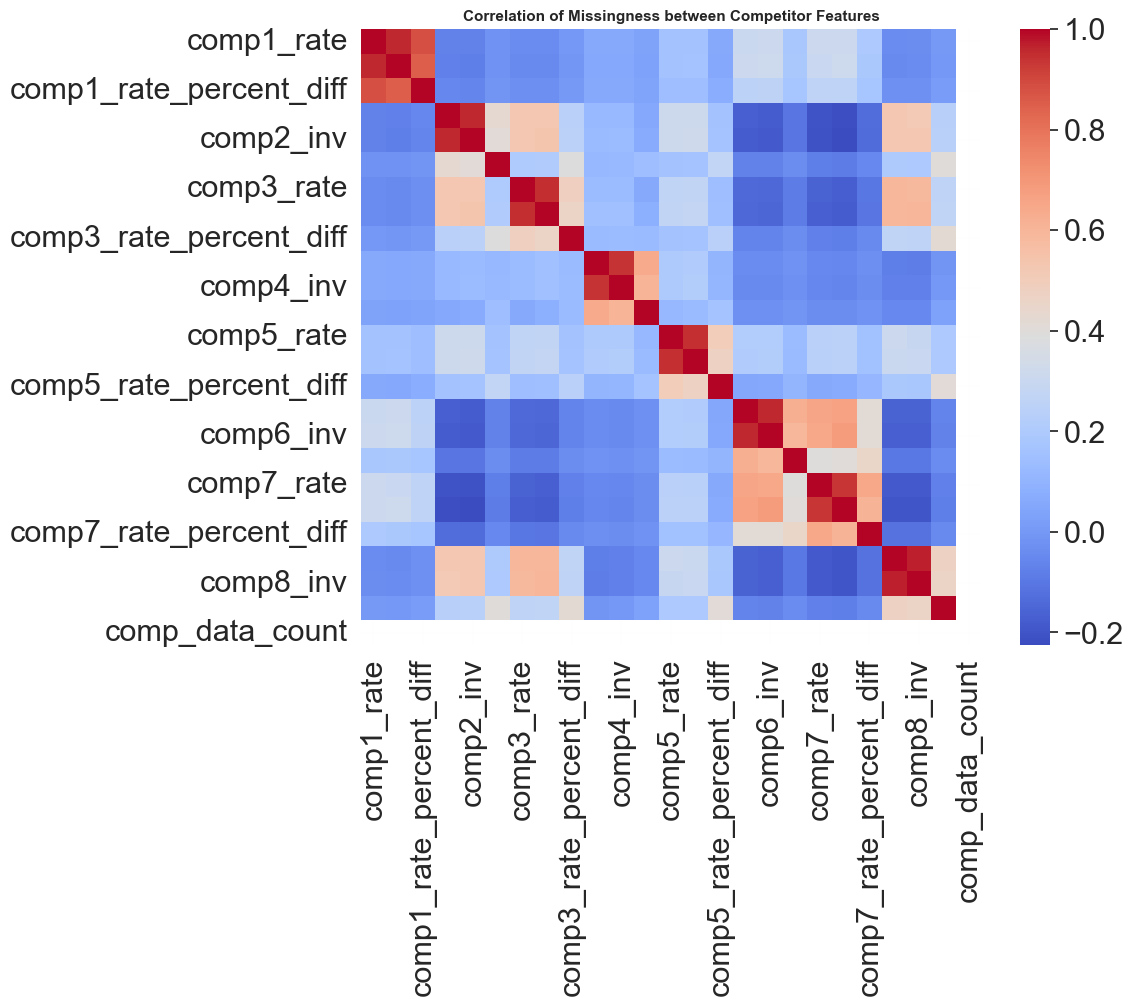

In [18]:
# check if competitor columns are missing simultaneously
comp_cols = [c for c in df.columns if 'comp' in c]
plt.figure(figsize=(10, 8))
sns.heatmap(df[comp_cols].isnull().corr(), annot=False, cmap='coolwarm')
plt.title("Correlation of Missingness between Competitor Features")
plt.show()

Interpretation: competitor columns mostly are missing within a comeptitor themsleves- there is some higher correlation between competior 2&3 and 6 & 7. 

In [19]:
# check if prop_review_score missingness correlates with position
# i.e. does a lack of reviews lead to lower search placement?
print(df.groupby(df['prop_review_score'].isnull())['position'].mean())

prop_review_score
False    16.854939
True     17.728544
Name: position, dtype: float64


### Plots and descriptive statistics

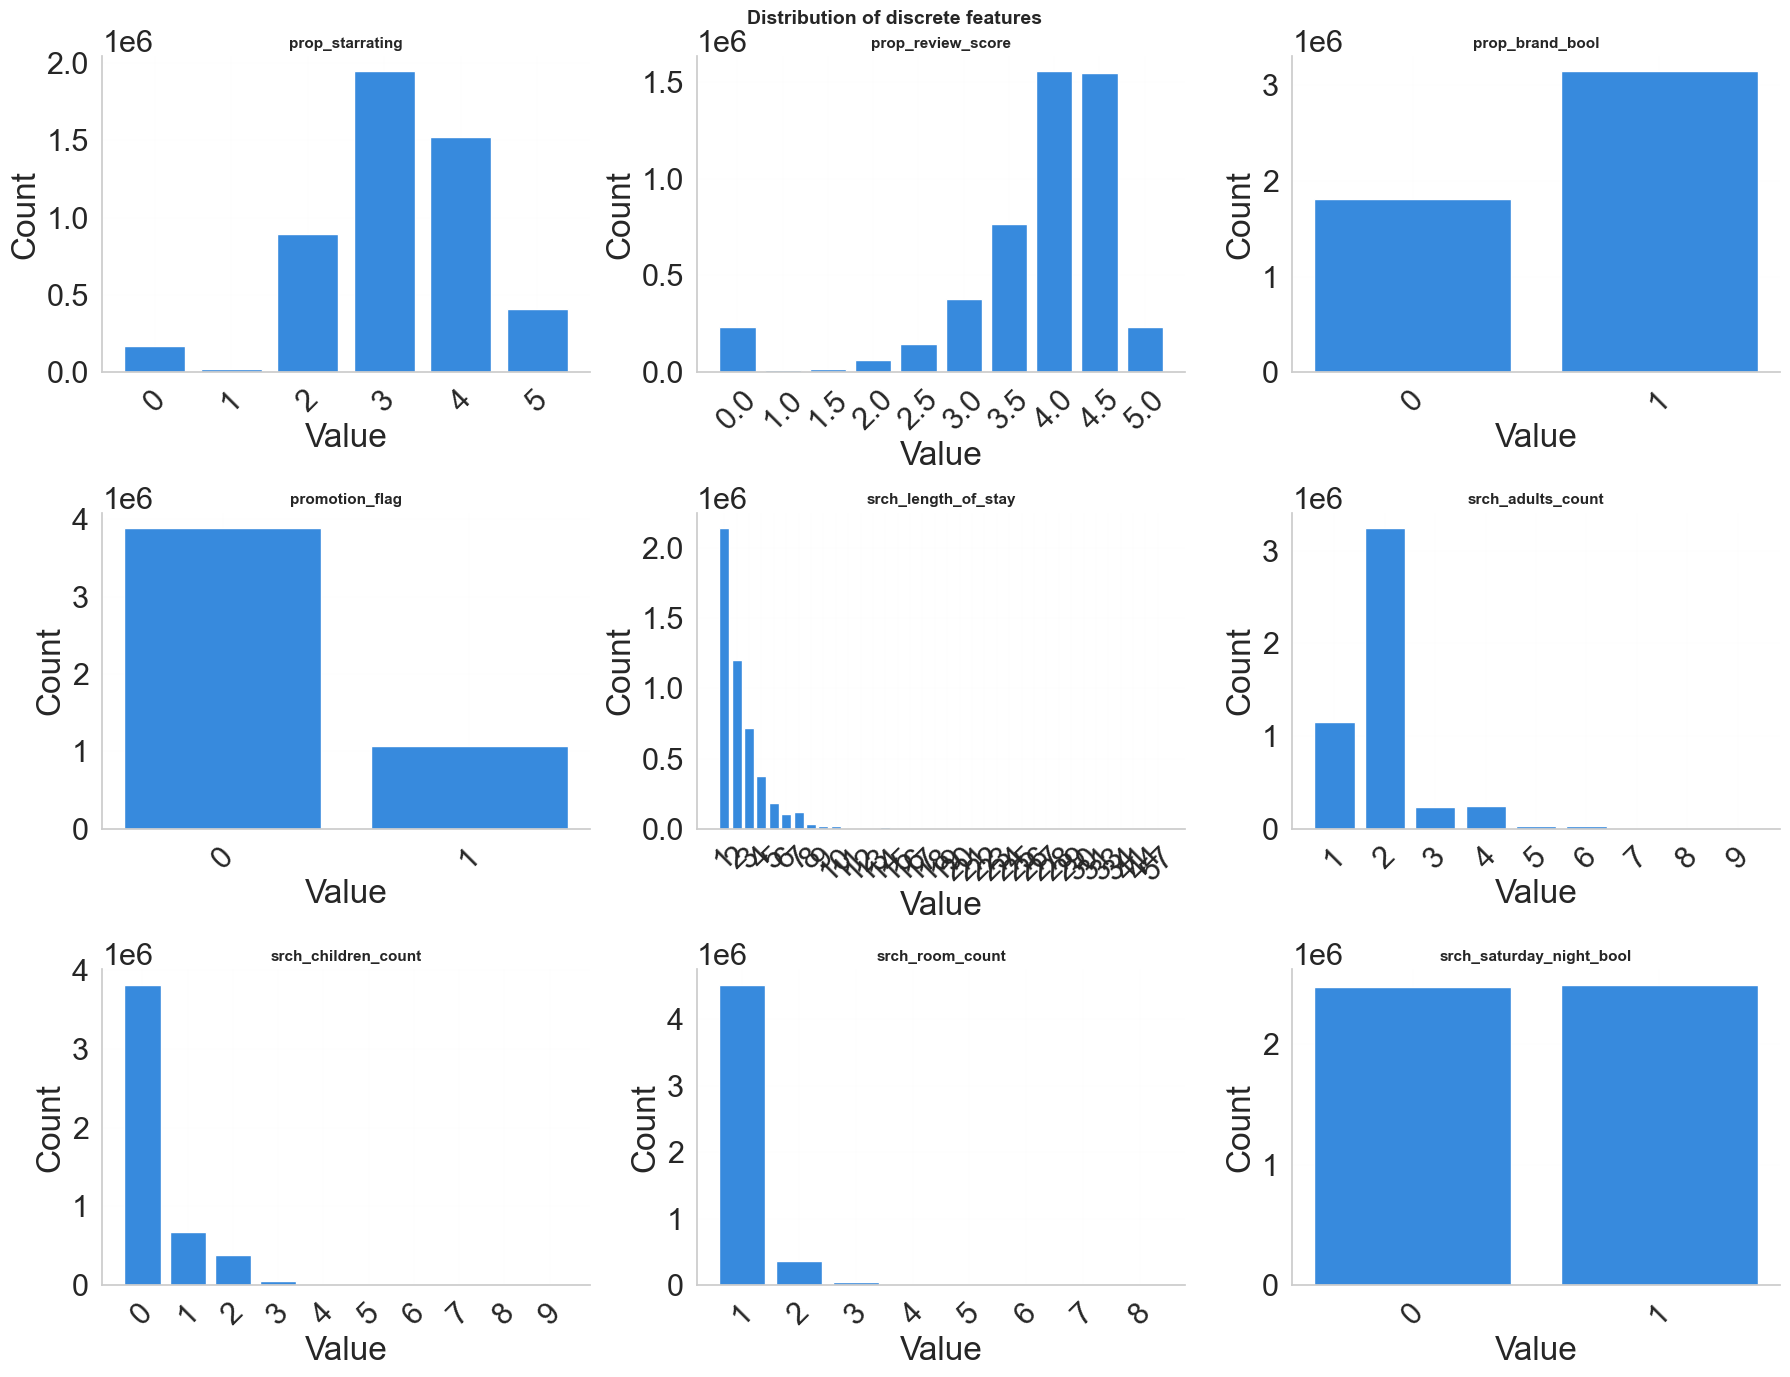

In [ ]:
# --- discrete variables: bar plots ---
discrete_vars = [
    'prop_starrating',
    'prop_review_score',        
    'prop_brand_bool',
    'promotion_flag',
    'srch_length_of_stay',
    'srch_adults_count',
    'srch_children_count',
    'srch_room_count',
    'srch_saturday_night_bool'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for ax, var in zip(axes, discrete_vars):
    counts = df[var].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color=BLUE, edgecolor='white')
    ax.set_title(var)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribution of discrete features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/discrete_distributions.png', dpi=150)
plt.show()

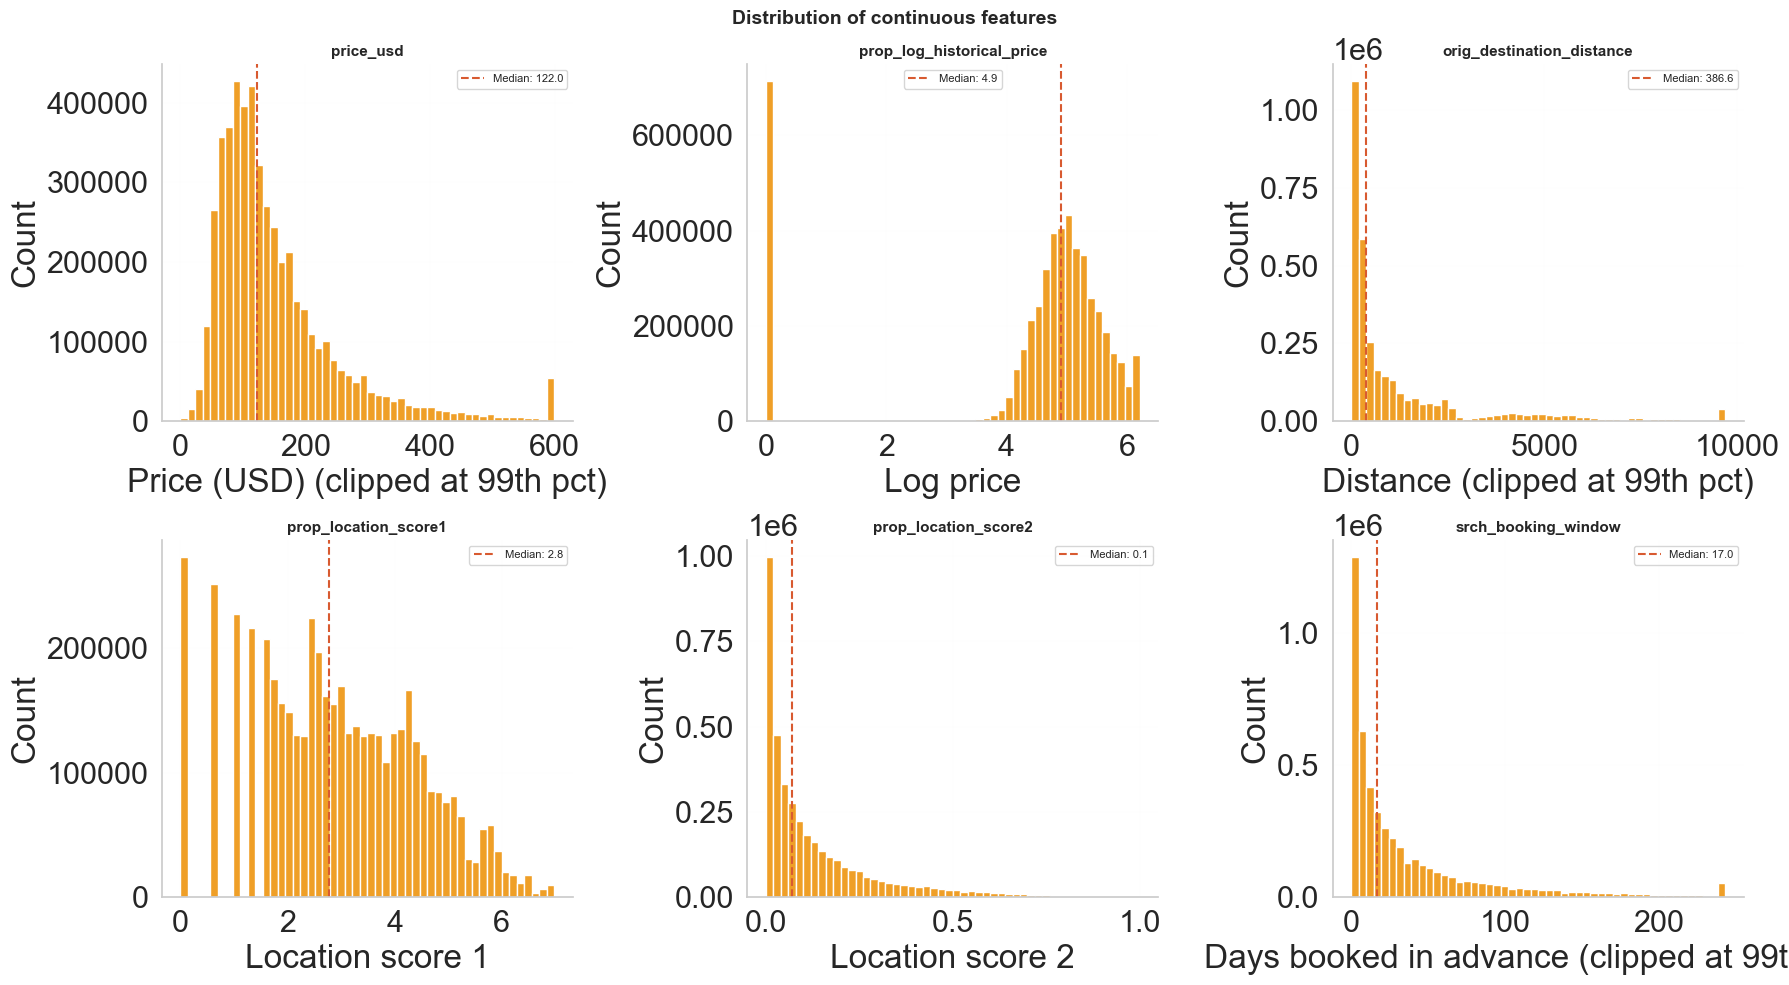

In [27]:
# --- continuous variables: histograms ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# each tuple: (column, xlabel, clip_at_quantile)
continuous_vars = [
    ('price_usd',                  'Price (USD)',           0.99),
    ('prop_log_historical_price',  'Log price',             None),
    ('orig_destination_distance',  'Distance',              0.99),
    ('prop_location_score1',       'Location score 1',      None),  
    ('prop_location_score2',       'Location score 2',      None),  
    ('srch_booking_window',        'Days booked in advance', 0.99),
]

for ax, (var, xlabel, clip_quantile) in zip(axes, continuous_vars):
    data = df[var].dropna()
    
    if clip_quantile:
        clip_val = data.quantile(clip_quantile)
        data     = data.clip(upper=clip_val)
        xlabel   = f'{xlabel} (clipped at {clip_quantile*100:.0f}th pct)'
    
    data.hist(bins=50, ax=ax, color=AMBER, edgecolor='white')
    ax.axvline(data.median(), color=CORAL, linestyle='--',
               label=f'Median: {data.median():.1f}')
    ax.set_title(var)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of continuous features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/continuous_distributions.png', dpi=150)
plt.show()

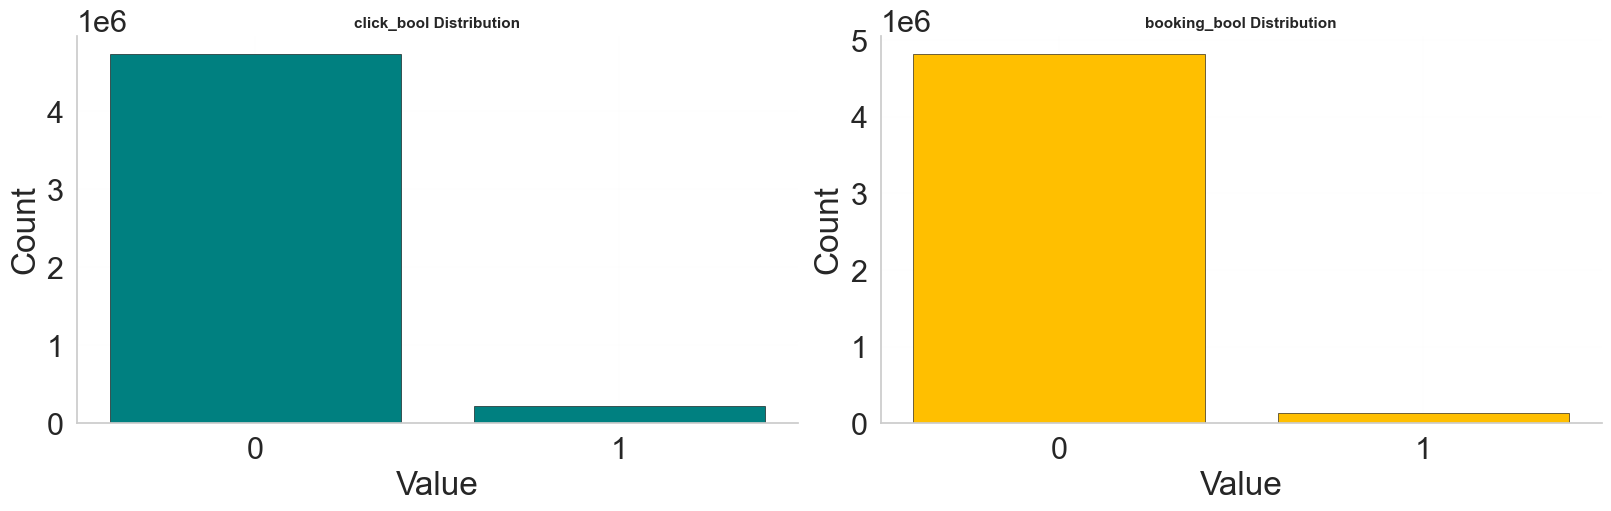

In [23]:
# plotting key target variables
important_vars = [ "click_bool", "booking_bool"]
colors = ['#008080', '#FFBF00']

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

for ax, var, color in zip(axes, important_vars, colors):
    # drop NA for plotting
    vals = df[var].dropna()

    # use value_counts for discrete/categorical-like numeric data
    counts = vals.value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values,
           color=color, edgecolor="black", linewidth=0.4)

    ax.set_title(f"{var} Distribution")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    # handle overlapping x-labels for review scores
    if var == "prop_review_score":
        ax.tick_params(axis="x", rotation=45)

plt.show()

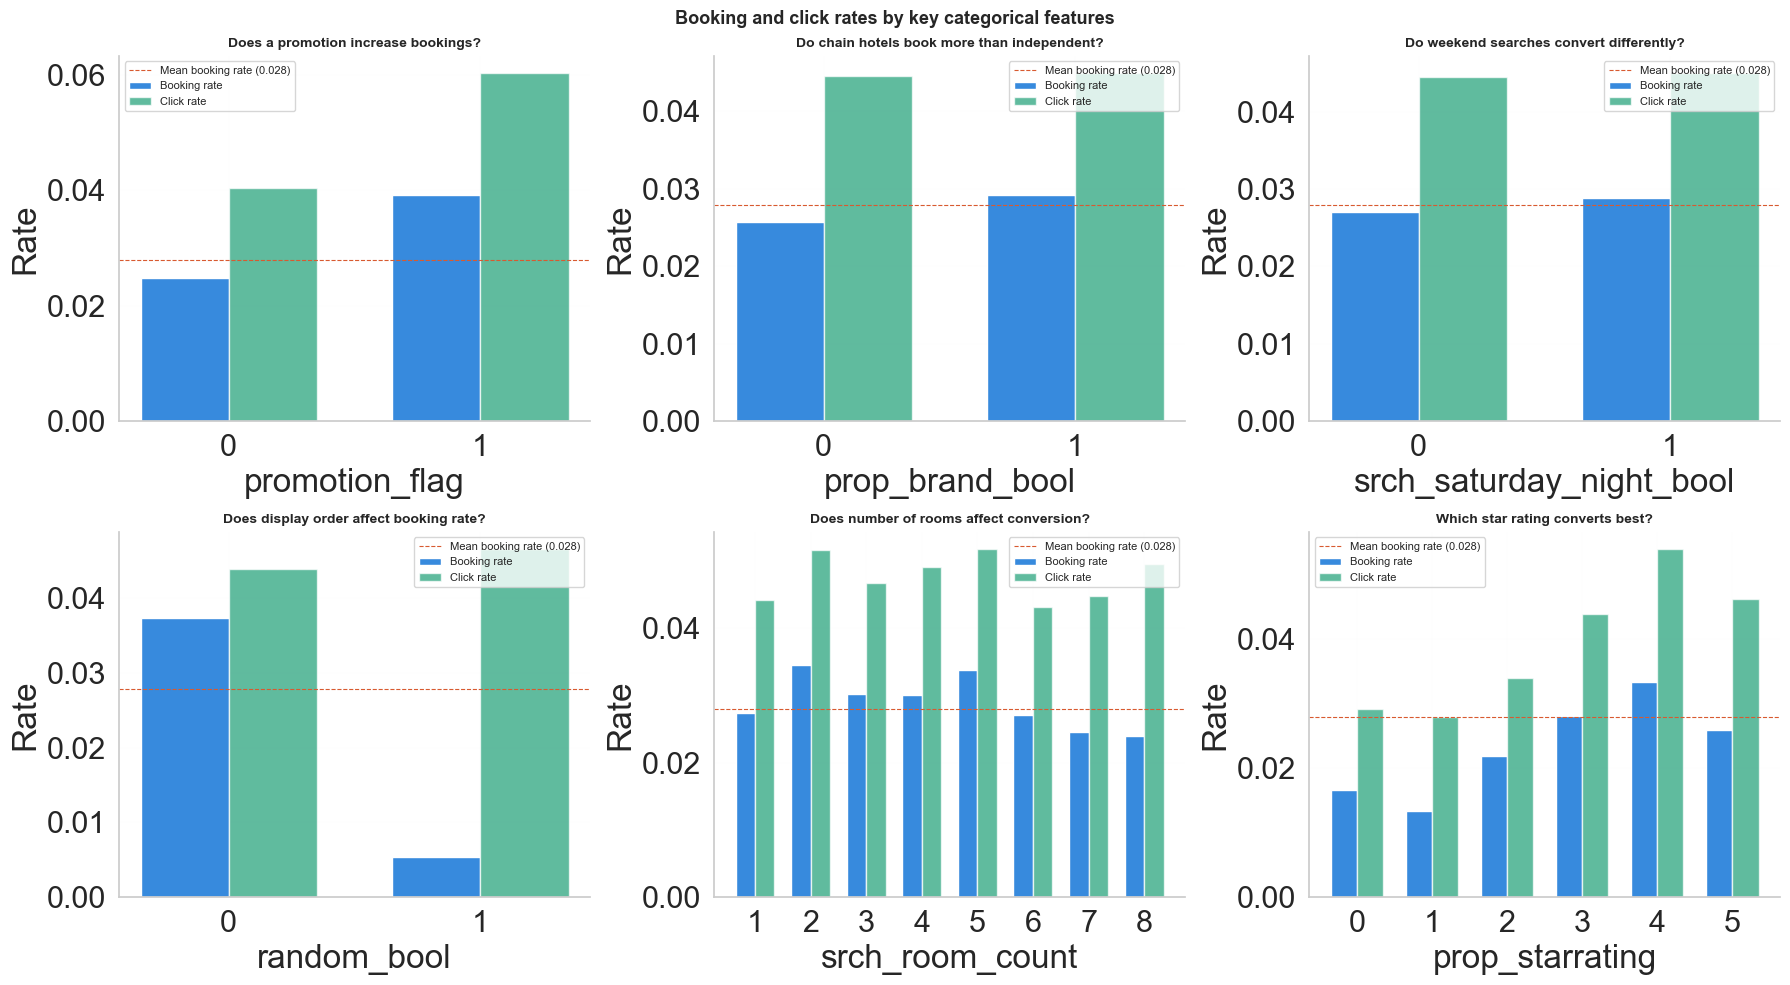

In [25]:
# variables where category plausibly affects booking rate
hue_vars = {
    'promotion_flag':        'Does a promotion increase bookings?',
    'prop_brand_bool':       'Do chain hotels book more than independent?',
    'srch_saturday_night_bool': 'Do weekend searches convert differently?',
    'random_bool':           'Does display order affect booking rate?',  
    'srch_room_count':       'Does number of rooms affect conversion?',
    'prop_starrating':       'Which star rating converts best?',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (var, question) in zip(axes, hue_vars.items()):
    
    # booking rate per category
    booking_rate = df.groupby(var)['booking_bool'].mean()
    click_rate   = df.groupby(var)['click_bool'].mean()
    
    x     = np.arange(len(booking_rate))
    width = 0.35
    
    ax.bar(x - width/2, booking_rate.values, 
           width, label='Booking rate', 
           color=BLUE, edgecolor='white')
    ax.bar(x + width/2, click_rate.values,   
           width, label='Click rate',   
           color=TEAL, alpha=0.7, edgecolor='white')
    
    # global baseline
    ax.axhline(df['booking_bool'].mean(), color=CORAL,
               linestyle='--', linewidth=0.8, 
               label=f'Mean booking rate ({df["booking_bool"].mean():.3f})')
    
    ax.set_xticks(x)
    ax.set_xticklabels(booking_rate.index.astype(str))
    ax.set_title(question, fontsize=10, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Rate')
    ax.legend(fontsize=8)

plt.suptitle('Booking and click rates by key categorical features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/booking_rates_by_category.png', dpi=150)
plt.show()

In [24]:
# FAIRNESS CHECK: does the promotion flag correlate with position bias?
# checking how the promotion flag correlates with the average position
promotion_stats = df.groupby('promotion_flag')['position'].mean().reset_index()

promotion_stats.columns = ['Promotion Flag', 'Average Position']
print(promotion_stats)
# We see that the promotion flag means the average position is higher

# BIAS: we use Independent Samples T-Test to check if this difference is statistically significant - if algorithm promotes discounted hotels
from scipy import stats

# separate data into two groups
group_no_promo = df[df['promotion_flag'] == 0]['position']
group_promo = df[df['promotion_flag'] == 1]['position']

#Welch's T-test
t_stat, p_value = stats.ttest_ind(group_no_promo, group_promo, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# interpretation
alpha = 0.05
if p_value < alpha:
    print("The difference is statistically significant (Reject H0).")
else:
    print("The difference is not statistically significant (Fail to reject H0).")



   Promotion Flag  Average Position
0               0         17.422649
1               1         14.795745
T-statistic: 230.9399
P-value: 0.0000e+00
The difference is statistically significant (Reject H0).


Since the dataset is very large, even small differences result in a statistically significant result, as in here. we should mention that while statistically significant, the practical significance (the ~2.6 rank jump) is what truly influences the user's likelihood to click or book.

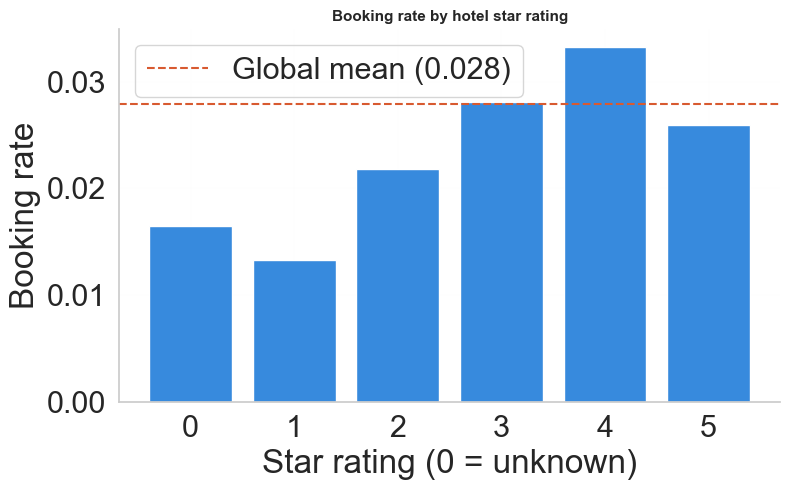

In [28]:
# plot: booking rate by star rating
fig, ax = plt.subplots(figsize=(8, 5))

star_booking = df.groupby('prop_starrating')['booking_bool'].mean()

ax.bar(star_booking.index.astype(str), star_booking.values,
       color=BLUE, edgecolor='white')
ax.axhline(df['booking_bool'].mean(), color=CORAL,
           linestyle='--', label=f'Global mean ({df["booking_bool"].mean():.3f})')
ax.set_xlabel('Star rating (0 = unknown)')
ax.set_ylabel('Booking rate')
ax.set_title('Booking rate by hotel star rating')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/booking_by_starrating.png', dpi=150)
plt.show()

In [32]:
# calculate relative position per search session
df['rel_position'] = df.groupby('srch_id')['position'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0
)

# compare the means
comparison = df.groupby(df['prop_review_score'].isnull())['rel_position'].mean()
print("Mean Relative Position (0 = Top, 1 = Bottom):")
print(comparison)

# checking the significance - delta
delta = comparison[True] - comparison[False]
print(f"\nRanking Penalty for Missing Reviews: {delta:.4f}")

Mean Relative Position (0 = Top, 1 = Bottom):
prop_review_score
False    0.510327
True     0.622771
Name: rel_position, dtype: float64

Ranking Penalty for Missing Reviews: 0.1124


Interpretation: properties without a review score are, on average, ranked 11.24% lower in search results than those with reviews.
Q: should we do anything about this?

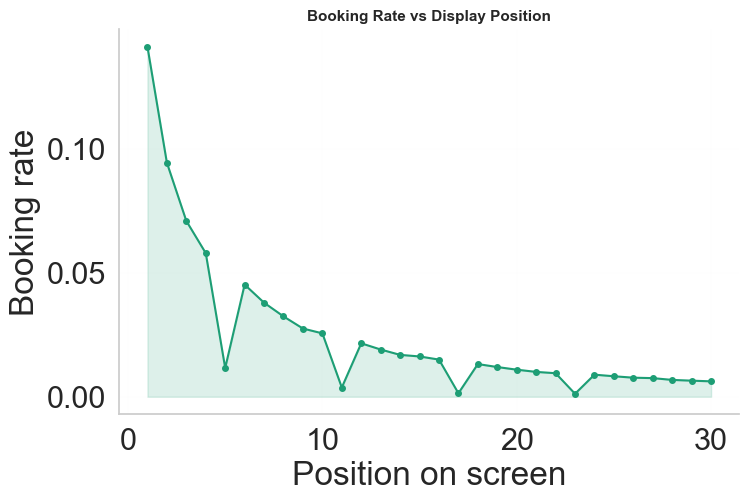

In [29]:
#booking rate by position on the search results page
fig, ax = plt.subplots(figsize=(8, 5))

# use only first 30 positions to keep it readable
pos_booking = (df[df['position'] <= 30]
               .groupby('position')['booking_bool'].mean())
ax.plot(pos_booking.index, pos_booking.values, 
             color=TEAL, marker='o', markersize=4)
ax.fill_between(pos_booking.index, pos_booking.values, 
                     alpha=0.15, color=TEAL)
ax.set_xlabel('Position on screen')
ax.set_ylabel('Booking rate')
ax.set_title('Booking Rate vs Display Position')
plt.show()
# position bias: booking rate drops with display position

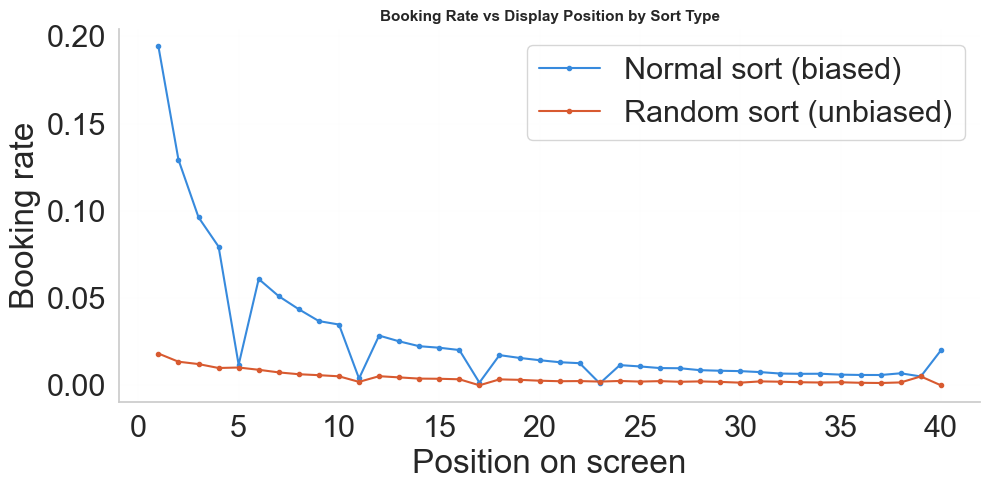

In [30]:
# position bias based on sorting:
# booking rate drops with display position, effect is stronger when sort order is not random
fig, ax = plt.subplots(figsize=(10, 5))

# split by random_bool to show bias is stronger in normal sort
for random_val, label, color in [(0, 'Normal sort (biased)', BLUE),
                                  (1, 'Random sort (unbiased)', CORAL)]:
    pos_booking = (df[df['random_bool'] == random_val]
                   .groupby('position')['booking_bool']
                   .mean())
    ax.plot(pos_booking.index, pos_booking.values,
            marker='o', markersize=3,
            label=label, color=color)

ax.set_xlabel('Position on screen')
ax.set_ylabel('Booking rate')
ax.set_title('Booking Rate vs Display Position by Sort Type')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/position_bias.png', dpi=150)
plt.show()

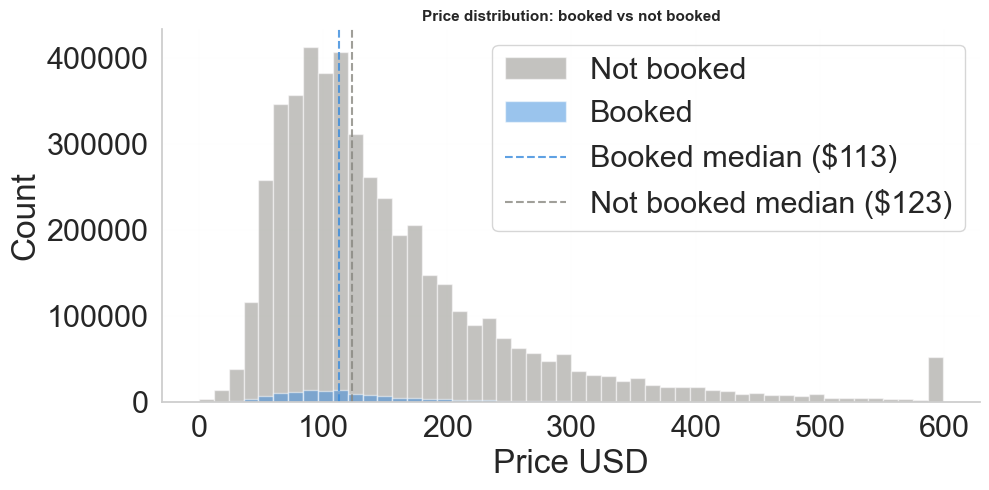

In [31]:
# price distribution booked vs not booked
fig, ax = plt.subplots(figsize=(10, 5))

clip_val = df['price_usd'].quantile(0.99) # clipping at 0.99 percentile

df[df['booking_bool'] == 0]['price_usd'].clip(0, clip_val).hist(
    bins=50, alpha=0.5, label='Not booked', ax=ax, color=GRAY)
df[df['booking_bool'] == 1]['price_usd'].clip(0, clip_val).hist(
    bins=50, alpha=0.5, label='Booked', ax=ax, color=BLUE)

ax.axvline(df[df['booking_bool'] == 1]['price_usd'].median(),
           color=BLUE, linestyle='--', alpha=0.8,
           label=f'Booked median (${df[df["booking_bool"]==1]["price_usd"].median():.0f})')
ax.axvline(df[df['booking_bool'] == 0]['price_usd'].median(),
           color=GRAY, linestyle='--', alpha=0.8,
           label=f'Not booked median (${df[df["booking_bool"]==0]["price_usd"].median():.0f})')

ax.set_xlabel(f'Price USD')
ax.set_ylabel('Count')
ax.set_title('Price distribution: booked vs not booked')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/price_distribution.png', dpi=150)
plt.show()

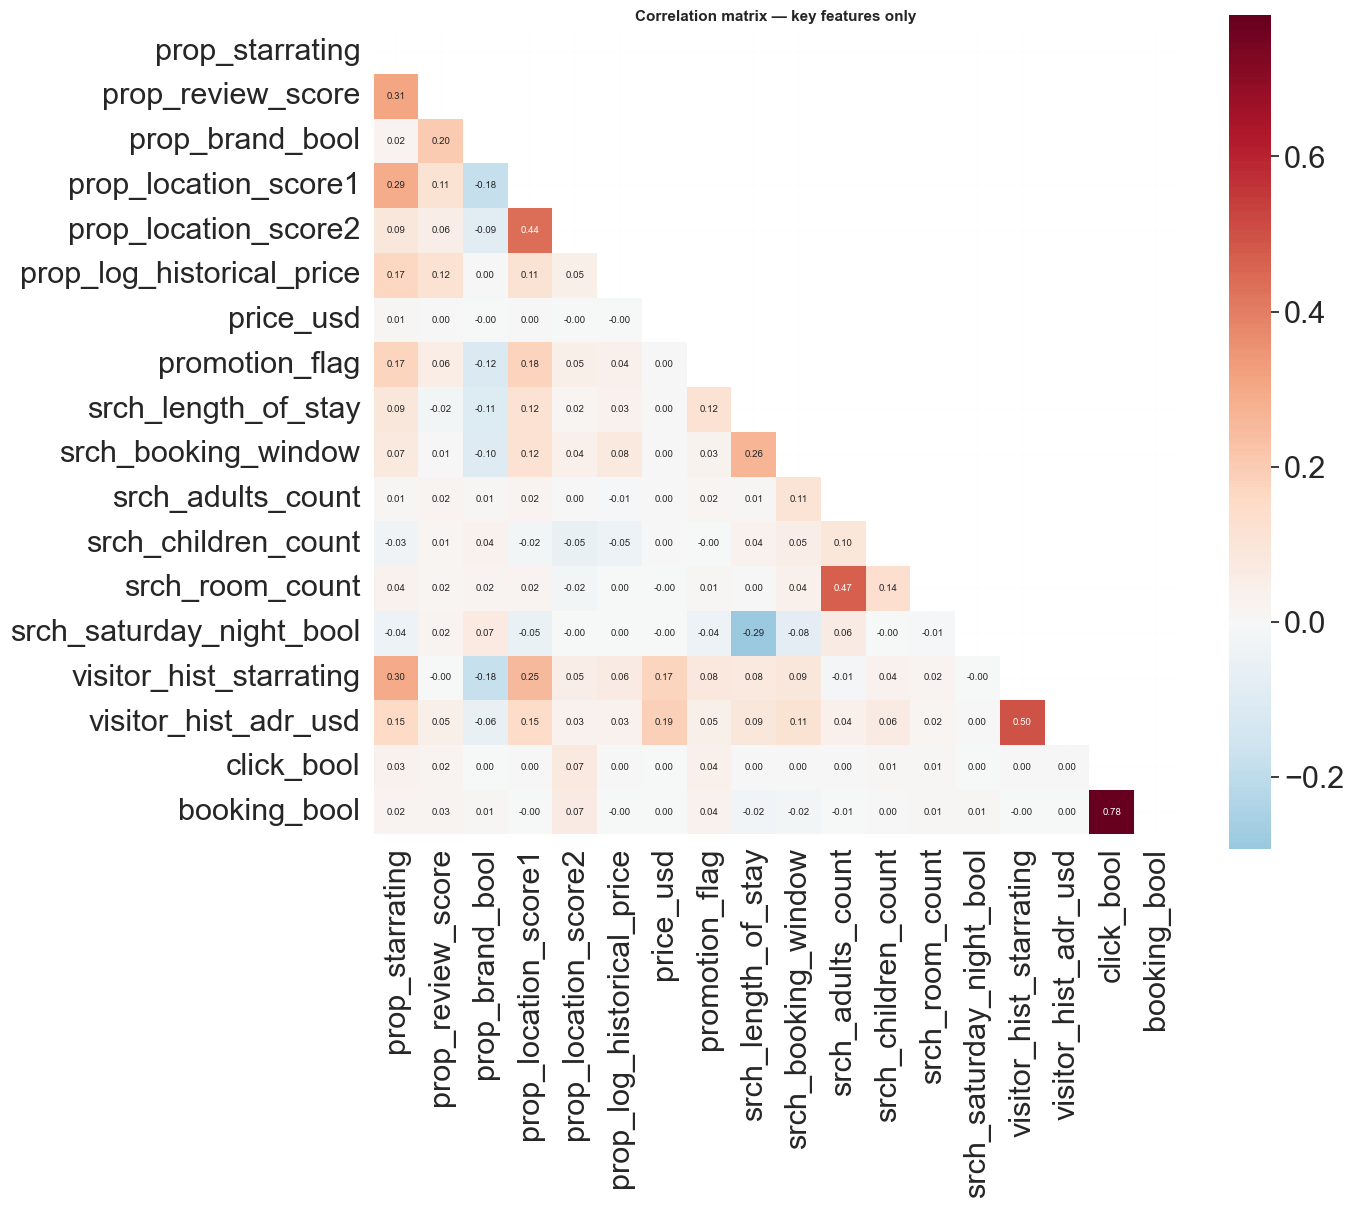

In [ ]:
# correlation matrix 
important_cols = [
    # hotel features
    'prop_starrating', 'prop_review_score', 'prop_brand_bool',
    'prop_location_score1', 'prop_location_score2', 
    'prop_log_historical_price',
    # price and promotion
    'price_usd', 'promotion_flag',
    # search features  
    'srch_length_of_stay', 'srch_booking_window',
    'srch_adults_count', 'srch_children_count', 'srch_room_count',
    'srch_saturday_night_bool',
    # user history
    'visitor_hist_starrating', 'visitor_hist_adr_usd',
    # target
    'click_bool', 'booking_bool'
]

corr = df[important_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr, 
    mask=mask,          # only show lower triangle
    cmap='RdBu_r',      # red=positive, blue=negative, white=zero
    center=0,
    annot=True, 
    fmt='.2f',
    annot_kws={'size': 7},
    square=True,
    ax=ax
)
ax.set_title('Correlation matrix — key features only')
plt.tight_layout()
plt.savefig('../figures/train_correlation_matrix.png', dpi=150)
plt.show()

### Imputation 

In [34]:
df_before_cleaning = df.copy()

In [ ]:
# null signifies there is no purchase history on the customer, hence set 0
df['new_customer'] = df['visitor_hist_starrating'].isnull().astype(int)
df['visitor_hist_starrating'] = df['visitor_hist_starrating'].fillna(0)
df['visitor_hist_adr_usd']    = df['visitor_hist_adr_usd'].fillna(0)

In [38]:
df['has_review_score'] = df['prop_review_score'].notnull().astype(int)

# conservative estimate: null means unknown review score, so fill with 0 (no reviews) 
# but keep flag to distinguish from confirmed 0
df['prop_review_score'] = df['prop_review_score'].fillna(0)

In [ ]:
df['has_loc_score2'] = df['prop_location_score2'].notnull().astype(int)

# impute per destination: hotels in the same destination share location characteristics
df['prop_location_score2'] = (
    df.groupby('srch_destination_id')['prop_location_score2']
    .transform(lambda x: x.fillna(x.median()) 
               if x.notnull().any() else x)
    .fillna(0)  # if entire destination has no score2, set 0
)

# score1 has few nulls — global median is fine
df['prop_location_score1'] = df['prop_location_score1'].fillna(
    df['prop_location_score1'].median()
)

In [42]:
(df["prop_location_score2"]).eq(0).sum()

np.int64(126660)

In [ ]:
# A null signifies there are no data (i.e. hotel did not register in any searches).
df['has_query_affinity'] = df['srch_query_affinity_score'].notnull().astype(int)
df['srch_query_affinity_score'] = df['srch_query_affinity_score'].fillna(0)
# 0  means "not searchable on internet"

In [46]:
# missing at random, try with destination
df['has_distance'] = df['orig_destination_distance'].notnull().astype(int)

df['orig_destination_distance'] = (
    df.groupby('srch_destination_id')['orig_destination_distance']
    .transform(lambda x: x.fillna(x.median())
               if x.notnull().any() else x)
    .fillna(df['orig_destination_distance'].median())
)

In [ ]:
# competitor variables
rate_cols = [f'comp{i}_rate' for i in range(1, 9)]
diff_cols = [f'comp{i}_rate_percent_diff' for i in range(1, 9)]

# 1. comp_score_sum: Sum of rates (-1,0,1)
df['comp_score_sum'] = df[rate_cols].sum(axis=1, skipna=True)

# 2. binary flag - is expedia cheaper / more expensive than any competitor
df['is_cheapest_any'] = (df[rate_cols] == 1).any(axis=1).astype(int)
df['is_expensive_any'] = (df[rate_cols] == -1).any(axis=1).astype(int)


In [48]:
# baseline booking rate - global mean
baseline = df['booking_bool'].mean()

plt.figure(figsize=(7, 6))
ax = sns.barplot(data=df, x='is_cheapest_any', y='booking_bool', palette='RdYlGn')
plt.axhline(baseline, color='red', linestyle='--', label=f'Global Baseline ({baseline:.2%})')

plt.title("Impact of Being the Cheapest Competitor on Booking Rate")
plt.ylabel("Mean Booking Rate")
plt.xlabel("Is Expedia the Cheapest? (0=No, 1=Yes)")
plt.legend(loc='upper right')
plt.show()

KeyboardInterrupt: 

In [50]:
# drop the rest of competitor data- contains more a lot of missing values
features = ['comp1_rate', "comp1_inv", "comp1_rate_percent_diff",
            'comp2_rate', "comp2_inv", "comp2_rate_percent_diff",
            'comp3_rate', "comp3_inv", "comp3_rate_percent_diff",
            'comp4_rate', "comp4_inv", "comp4_rate_percent_diff",
            'comp5_rate', "comp5_inv", "comp5_rate_percent_diff",
            'comp6_rate', "comp6_inv", "comp6_rate_percent_diff",
            'comp7_rate', "comp7_inv", "comp7_rate_percent_diff",
            'comp8_rate', "comp8_inv", "comp8_rate_percent_diff"]
df.drop(columns = features, inplace=True)

In [51]:
#check what columns are still missing data
missing_col_pct = (df.isnull().sum() / len(df)) * 100 # % of missing values per column
missing_col_pct = missing_col_pct.sort_values(ascending=False) # descending order sort
display(missing_col_pct[missing_col_pct > 0]) # only columns with some missing data

gross_bookings_usd    97.208949
dtype: float64

gross_bookings_usd  - we prevously checked and this is only present for listings where the booking was made. this can cause leakage, thus we drop it

In [52]:
df.drop(columns ="gross_bookings_usd", inplace=True)

### Feature Engineering

In [ ]:
# claude function
def feature_engineering(df, prop_stats=None, is_train=True):
    """
    prop_stats: precomputed hotel stats from training set
                pass None for training (will compute internally)
                pass the computed df for val/test
    """
    
    # --- within search features ---
    g = df.groupby('srch_id')
    df['price_mean']      = g['price_usd'].transform('mean')
    df['price_std']       = g['price_usd'].transform('std').fillna(0)
    df['price_ratio']     = df['price_usd'] / (df['price_mean'] + 1e-6)
    df['price_rank']      = g['price_usd'].transform('rank', method='min')
    df['price_rank_pct']  = g['price_usd'].transform('rank', pct=True)
    df['review_rank']     = g['prop_review_score'].transform(
                               'rank', ascending=False, method='min')
    df['loc1_rank']       = g['prop_location_score1'].transform(
                               'rank', ascending=False, method='min')
    df['starrating_rank'] = g['prop_starrating'].transform(
                               'rank', ascending=False, method='min')

    # --- user-hotel match ---
    df['star_vs_hist']         = (df['prop_starrating'] - 
                                   df['visitor_hist_starrating'])
    df['price_vs_hist']        = (df['price_usd'] - 
                                   df['visitor_hist_adr_usd'])
    df['price_vs_hist_ratio']  = (df['price_usd'] / 
                                   (df['visitor_hist_adr_usd'] + 1e-6))

    # --- destination features ---
    d = df.groupby('srch_destination_id')
    df['dest_mean_price']  = d['price_usd'].transform('mean')
    df['dest_price_ratio'] = df['price_usd'] / (df['dest_mean_price'] + 1e-6)
    df['dest_mean_review'] = d['prop_review_score'].transform('mean')
    df['dest_review_diff'] = df['prop_review_score'] - df['dest_mean_review']

    # --- datetime ---
    df['date_time']       = pd.to_datetime(df['date_time'])
    df['month']           = df['date_time'].dt.month
    df['day_of_week']     = df['date_time'].dt.dayofweek
    df['hour']            = df['date_time'].dt.hour
    df['is_last_minute']  = (df['srch_booking_window'] <= 3).astype(int)
    df['is_long_stay']    = (df['srch_length_of_stay'] >= 7).astype(int)

    # --- interactions ---
    df['quality_score']          = (df['prop_starrating'] * 
                                     df['prop_review_score'])
    df['location_score_combined'] = (df['prop_location_score1'] * 0.7 + 
                                      df['prop_location_score2'] * 0.3)
    df['value_score']            = (df['prop_review_score'] / 
                                     (df['price_rank'] + 1e-6))

    # --- competitive ---
    rate_cols = [f'comp{i}_rate' for i in range(1, 9) 
                 if f'comp{i}_rate' in df.columns]
    diff_cols = [f'comp{i}_rate_percent_diff' for i in range(1, 9)
                 if f'comp{i}_rate_percent_diff' in df.columns]
    df['n_comp_cheaper'] = (df[rate_cols] ==  1).sum(axis=1)
    df['n_comp_pricier'] = (df[rate_cols] == -1).sum(axis=1)
    df['comp_advantage'] =  df['n_comp_cheaper'] - df['n_comp_pricier']
    df['comp_avg_diff']  =  df[diff_cols].mean(axis=1, skipna=True).fillna(0)

    # --- hotel historical stats ---
    # only compute from training data to avoid leakage
    if is_train:
        prop_stats = df.groupby('prop_id').agg(
            prop_booking_rate  = ('booking_bool', 'mean'),
            prop_click_rate    = ('click_bool',   'mean'),
            prop_mean_price    = ('price_usd',    'mean'),
            prop_std_price     = ('price_usd',    'std'),
            prop_n_appearances = ('booking_bool', 'count'),
        ).reset_index()
    
    df = df.merge(prop_stats, on='prop_id', how='left')
    global_booking_rate = 0.04  # approximate — replace with actual
    df['prop_booking_rate'] = df['prop_booking_rate'].fillna(global_booking_rate)
    df['prop_click_rate']   = df['prop_click_rate'].fillna(0.25)
    df['prop_std_price']    = df['prop_std_price'].fillna(0)
    df['prop_n_appearances']= df['prop_n_appearances'].fillna(0)

    return df, prop_stats


# usage
train, prop_stats = feature_engineering(train, is_train=True)
val,   _          = feature_engineering(val,   prop_stats=prop_stats, 
                                               is_train=False)
test,  _          = feature_engineering(test,  prop_stats=prop_stats, 
                                               is_train=False)